# Healthcare AI: from raw data to a live Streamlit app

In this notebook, I:

1. Explored a real clinical dataset
2. Trained and compared three machine-learning models
3. Chosen a model using a metric that makes sense in healthcare (recall, not accuracy)
4. Saved the model as a reusable artifact
5. Built a multi-page Streamlit web application around it
6. Served that app from Colab on a public URL
7. Tested the prediction path systematically
8. Packaged everything for permanent deployment on Streamlit Community Cloud

**The case study:** a screening assistant for breast masses. It takes eight measurements
computed from a fine-needle-aspirate image and estimates the probability that the mass is
malignant.


## 0. Install the libraries

Colab already has pandas, numpy, scikit-learn and matplotlib. Streamlit is the only addition.

In [1]:
!pip install -q streamlit
import streamlit, sklearn, pandas, numpy
print("streamlit   ", streamlit.__version__)
print("scikit-learn", sklearn.__version__)
print("pandas      ", pandas.__version__)
print("numpy       ", numpy.__version__)
print("\nWrite these exact numbers into requirements.txt later — a version mismatch")
print("between here and the cloud is the single most common deployment failure.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 42.5 MB/s eta 0:00:00
streamlit    1.64.0
scikit-learn 1.6.1
pandas       2.2.3
numpy        2.1.3

Write these exact numbers into requirements.txt later — a version mismatch
between here and the cloud is the single most common deployment failure.


## 1. Frame the problem before touching the data

Three questions I made myself answer before writing any code:

| Question | Our answer |
|---|---|
| **Who uses the output?** | A clinician triaging biopsy results — not a patient, not automatically |
| **What is the cost of each error?** | A false negative (missed malignancy) is far worse than a false positive (unnecessary follow-up) |
| **Which metric follows from that?** | **Recall** on the malignant class. Accuracy would hide the errors that matter |


In [2]:
import json, os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.inspection import permutation_importance
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report,
                             roc_curve, ConfusionMatrixDisplay)

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("Imports ready.")

Imports ready.


## 2. Load and inspect the data

Note the target encoding. scikit-learn ships this dataset with `0 = malignant`, which is
backwards for our purpose: the class we want to *detect* should be `1`, so that
"recall" and "precision" refer to malignancy without mental gymnastics.

In [3]:
data = load_breast_cancer(as_frame=True)
df = data.frame.copy()

# Re-encode so that 1 = malignant (the class we are screening for)
df["target"] = (data.target == 0).astype(int)

print("Rows, columns:", df.shape)
print("\nClass balance:")
print(df["target"].value_counts().rename({0: "Benign (0)", 1: "Malignant (1)"}))
print("\nMissing values:", int(df.isna().sum().sum()))
df.head()

Rows, columns: (569, 31)

Class balance:
target
Benign (0)       357
Malignant (1)    212
Name: count, dtype: int64

Missing values: 0


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1


In [4]:
# Quick look at the numeric spread of a few columns
df[["mean radius", "mean texture", "mean area", "mean concave points", "target"]].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.13,3.52,6.98,11.70,13.37,15.78,28.11
mean texture,569.0,19.29,4.30,9.71,16.17,18.84,21.80,39.28
mean area,569.0,654.89,351.91,143.50,420.30,551.10,782.70,2501.00
mean concave points,569.0,0.05,0.04,0.00,0.02,0.03,0.07,0.20
target,569.0,0.37,0.48,0.00,0.00,0.00,1.00,1.00


### 2.1 Visual exploration

Three plots worth walking through: class balance (is the problem imbalanced?),
distribution separation (is the signal even there?), and correlation (are features redundant?).

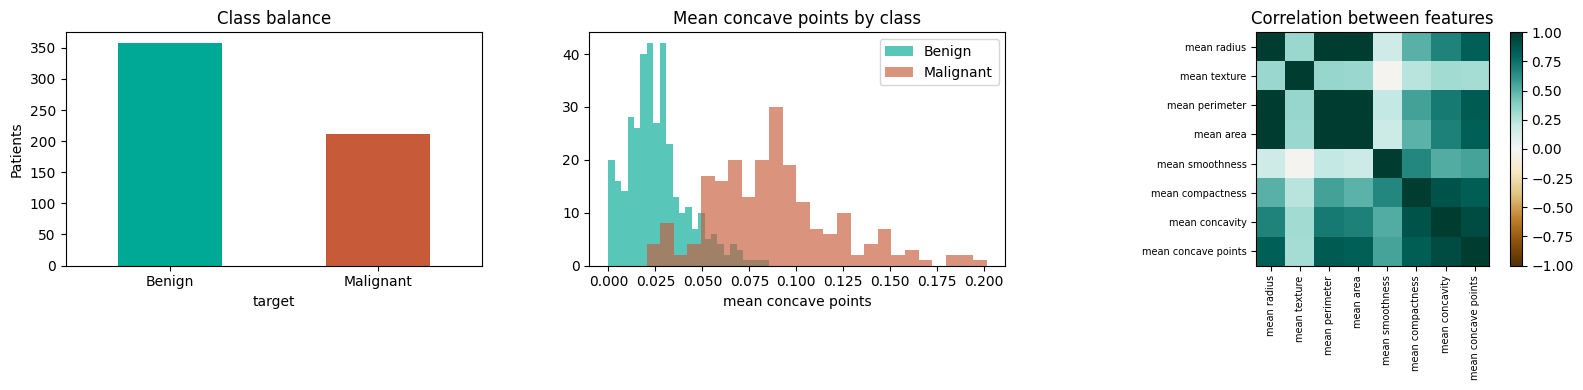

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# (a) class balance
df["target"].value_counts().sort_index().plot(
    kind="bar", ax=axes[0], color=["#00A896", "#C75B39"], rot=0)
axes[0].set_xticklabels(["Benign", "Malignant"])
axes[0].set_title("Class balance")
axes[0].set_ylabel("Patients")

# (b) does one feature separate the classes?
for cls, colour, name in [(0, "#00A896", "Benign"), (1, "#C75B39", "Malignant")]:
    axes[1].hist(df.loc[df.target == cls, "mean concave points"],
                 bins=25, alpha=0.65, color=colour, label=name)
axes[1].set_title("Mean concave points by class")
axes[1].set_xlabel("mean concave points")
axes[1].legend()

# (c) redundancy between candidate features
cand = ["mean radius", "mean texture", "mean perimeter", "mean area",
        "mean smoothness", "mean compactness", "mean concavity", "mean concave points"]
im = axes[2].imshow(df[cand].corr(), cmap="BrBG", vmin=-1, vmax=1)
axes[2].set_xticks(range(len(cand)));  axes[2].set_xticklabels(cand, rotation=90, fontsize=7)
axes[2].set_yticks(range(len(cand)));  axes[2].set_yticklabels(cand, fontsize=7)
axes[2].set_title("Correlation between features")
fig.colorbar(im, ax=axes[2], fraction=0.046)

plt.tight_layout(); plt.show()

**What the plots tell us**

- The classes are imbalanced roughly 63/37 — enough that plain accuracy is misleading, so we
  stratify every split and report recall separately.
- `mean concave points` separates the two groups strongly. There is real signal here.
- `mean radius`, `mean perimeter` and `mean area` are almost perfectly correlated — they measure
  the same thing three ways. We keep them anyway for this demo (tree and kernel models cope
  fine), but it's the kind of redundancy worth noticing before trusting any single feature's importance score.

## 3. Choose the features the app will ask for

A deployed app is a form a human has to fill in. Thirty input boxes is a form nobody completes.
We keep the eight "mean" measurements: clinically interpretable, quick to enter, and enough
for strong performance.

**This trade-off is a design decision, not a statistical one** — fewer features means a usable
app and slightly lower ceiling accuracy.

In [6]:
FEATURES = ["mean radius", "mean texture", "mean perimeter", "mean area",
            "mean smoothness", "mean compactness", "mean concavity",
            "mean concave points"]

X = df[FEATURES]
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE)

print(f"Training set: {X_train.shape[0]} patients")
print(f"Test set:     {X_test.shape[0]} patients  (held back, never seen during training)")
print(f"Malignant proportion — train {y_train.mean():.2%}, test {y_test.mean():.2%}")

Training set: 455 patients
Test set:     114 patients  (held back, never seen during training)
Malignant proportion — train 37.36%, test 36.84%


## 4. Train three models — inside a Pipeline

**The most important line in this notebook:**

```python
Pipeline([("scaler", StandardScaler()), ("model", clf)])
```

Wrapping the scaler and the estimator in one object means the saved `.pkl` contains *both*.
The app can hand it raw measurements and the scaling happens automatically, identically to
training. Save a bare estimator instead, and forgetting to scale in the app produces confident,
completely wrong predictions **with no error message** — the classic deployment bug.

In [7]:
candidates = {
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    "Random Forest":       RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE),
    "SVM (RBF kernel)":    SVC(probability=True, random_state=RANDOM_STATE),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results, fitted = [], {}

for name, clf in candidates.items():
    pipe = Pipeline([("scaler", StandardScaler()), ("model", clf)])

    cv_auc = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="roc_auc")
    pipe.fit(X_train, y_train)

    pred  = pipe.predict(X_test)
    proba = pipe.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "CV ROC-AUC": cv_auc.mean(),
        "CV std": cv_auc.std(),
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1": f1_score(y_test, pred),
        "Test ROC-AUC": roc_auc_score(y_test, proba),
    })
    fitted[name] = pipe

comparison = (pd.DataFrame(results)
              .sort_values("Recall", ascending=False)
              .reset_index(drop=True))
comparison.round(4)

,Model,CV ROC-AUC,CV std,Accuracy,Precision,Recall,F1,Test ROC-AUC
0,SVM (RBF kernel),0.9863,0.0072,0.9649,0.9524,0.9524,0.9524,0.9868
1,Logistic Regression,0.9856,0.0059,0.9386,0.9070,0.9286,0.9176,0.9845
2,Random Forest,0.9854,0.0066,0.9211,0.9024,0.8810,0.8916,0.9864


In [8]:
BEST_NAME = comparison.loc[0, "Model"]
best_model = fitted[BEST_NAME]

print(f"Selected: {BEST_NAME}")
print("\nSelected on RECALL, not accuracy. In screening, a missed malignancy costs")
print("far more than a false alarm, and every model here is within ~2 points on")
print("accuracy anyway — so accuracy would not have distinguished them meaningfully.")

Selected: SVM (RBF kernel)

Selected on RECALL, not accuracy. In screening, a missed malignancy costs
far more than a false alarm, and every model here is within ~2 points on
accuracy anyway — so accuracy would not have distinguished them meaningfully.


## 5. Evaluate properly

Four artefacts every healthcare model report should contain: confusion matrix,
per-class report, ROC curve, and a threshold analysis.

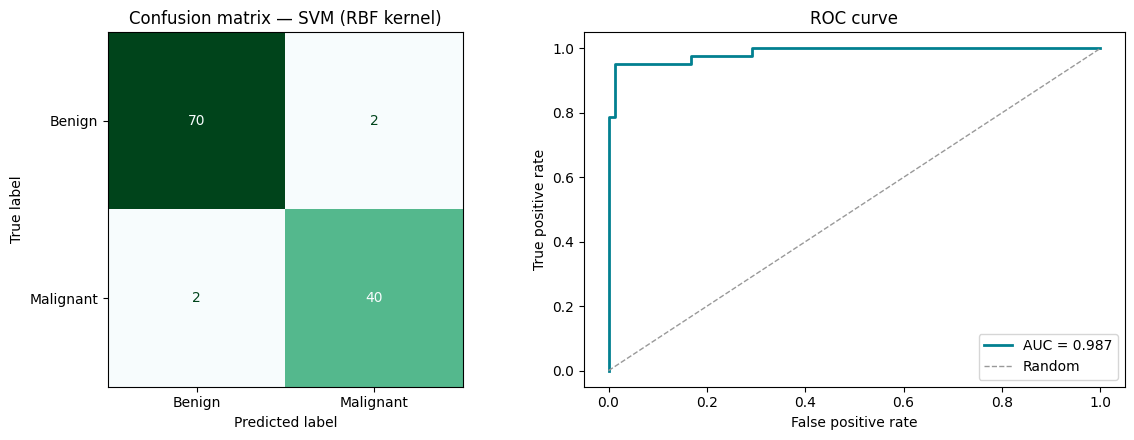

              precision    recall  f1-score   support

      Benign      0.972     0.972     0.972        72
   Malignant      0.952     0.952     0.952        42

    accuracy                          0.965       114
   macro avg      0.962     0.962     0.962       114
weighted avg      0.965     0.965     0.965       114

False negatives (missed malignancies): 2   <-- the number that matters clinically
False positives (unnecessary alarm):   2


In [9]:
y_pred  = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred),
    display_labels=["Benign", "Malignant"]
).plot(ax=axes[0], cmap="BuGn", colorbar=False)
axes[0].set_title(f"Confusion matrix — {BEST_NAME}")

fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, color="#028090", lw=2,
             label=f"AUC = {roc_auc_score(y_test, y_proba):.3f}")
axes[1].plot([0, 1], [0, 1], "--", color="#999999", lw=1, label="Random")
axes[1].set_xlabel("False positive rate"); axes[1].set_ylabel("True positive rate")
axes[1].set_title("ROC curve"); axes[1].legend()

plt.tight_layout(); plt.show()

print(classification_report(y_test, y_pred, target_names=["Benign", "Malignant"], digits=3))

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
print(f"False negatives (missed malignancies): {fn}   <-- the number that matters clinically")
print(f"False positives (unnecessary alarm):   {fp}")

### 5.1 The decision threshold is a clinical choice, not a default

`model.predict()` silently uses 0.5. Nothing about medicine says 0.5 is right. Lowering the
threshold catches more malignancies and raises false alarms. The table below is the real argument a hospital would have to have before picking a
threshold — I wanted to see that trade-off in actual numbers instead of just accepting 0.5.

In [10]:
rows = []
for t in [0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80]:
    pred_t = (y_proba >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred_t).ravel()
    rows.append({
        "Threshold": t,
        "Recall (caught)": recall_score(y_test, pred_t),
        "Precision": precision_score(y_test, pred_t, zero_division=0),
        "Missed malignancies": fn,
        "False alarms": fp,
    })
pd.DataFrame(rows).round(3)

,Threshold,Recall (caught),Precision,Missed malignancies,False alarms
0,0.2,0.952,0.851,2,7
1,0.3,0.952,0.870,2,6
2,0.4,0.952,0.909,2,4
3,0.5,0.952,0.952,2,2
4,0.6,0.952,0.952,2,2
5,0.7,0.905,0.974,4,1
6,0.8,0.881,0.974,5,1


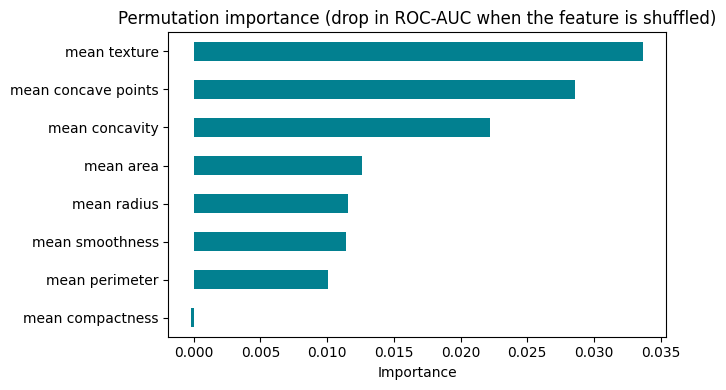

In [11]:
# Model-agnostic feature importance — works for SVM, forests and linear models alike
imp = permutation_importance(best_model, X_test, y_test,
                             n_repeats=10, random_state=RANDOM_STATE, scoring="roc_auc")
importance = pd.Series(imp.importances_mean, index=FEATURES).sort_values()

plt.figure(figsize=(7, 4))
importance.plot(kind="barh", color="#028090")
plt.title("Permutation importance (drop in ROC-AUC when the feature is shuffled)")
plt.xlabel("Importance"); plt.tight_layout(); plt.show()

## 6. Save the artifacts the app will load

Three files leave this notebook:

| File | Contents | Why the app needs it |
|---|---|---|
| `model.pkl` | the fitted **Pipeline** (scaler + model) | to make predictions |
| `metadata.json` | feature names **in training order**, input ranges, metrics, importances | to build the form and the model card, and to prevent column-order bugs |
| `sample_patients.csv` | three real test-set cases | so a demo never starts on a blank form |

Saving the feature order explicitly is not optional. scikit-learn matches columns by
**position**, so a DataFrame built in a different order predicts nonsense without complaining.

In [12]:
metadata = {
    "features": FEATURES,
    "target_names": ["Benign", "Malignant"],
    "model_name": BEST_NAME,
    "threshold": 0.5,
    "n_samples": int(len(df)),
    "n_positive": int(df["target"].sum()),
    "metrics": {
        "accuracy":  float(accuracy_score(y_test, y_pred)),
        "precision": float(precision_score(y_test, y_pred)),
        "recall":    float(recall_score(y_test, y_pred)),
        "f1":        float(f1_score(y_test, y_pred)),
        "roc_auc":   float(roc_auc_score(y_test, y_proba)),
    },
    "importance": {f: float(v) for f, v in zip(FEATURES, imp.importances_mean)},
    "feature_ranges": {f: [float(X[f].min()), float(X[f].max()), float(X[f].median())]
                       for f in FEATURES},
}

joblib.dump(best_model, "model.pkl", compress=3)          # compress=3 keeps it well under GitHub's 100 MB limit
with open("metadata.json", "w") as fh:
    json.dump(metadata, fh, indent=2)

# Three real cases for the demo dropdown
examples = []
for label, idx in [
    ("Example 1 - benign case",     X_test[y_test == 0].index[0]),
    ("Example 2 - malignant case",  X_test[y_test == 1].index[0]),
    ("Example 3 - borderline case", X_test.index[np.argmin(np.abs(y_proba - 0.5))]),
]:
    rec = {"label": label}; rec.update(X.loc[idx].to_dict()); examples.append(rec)
pd.DataFrame(examples).to_csv("sample_patients.csv", index=False)

print(f"model.pkl          {os.path.getsize('model.pkl')/1024:.1f} KB")
print(f"metadata.json      {os.path.getsize('metadata.json')/1024:.1f} KB")
print(f"sample_patients.csv {os.path.getsize('sample_patients.csv')/1024:.1f} KB")

model.pkl          8.3 KB
metadata.json      1.5 KB
sample_patients.csv 0.4 KB


In [13]:
# Reload exactly as the app will, and confirm the round trip is lossless
reloaded = joblib.load("model.pkl")
meta_r   = json.load(open("metadata.json"))

case = X_test.iloc[[0]][meta_r["features"]]     # note: reindexed by the saved order
print("Notebook model :", best_model.predict_proba(case)[0][1])
print("Reloaded model :", reloaded.predict_proba(case)[0][1])
assert np.allclose(best_model.predict_proba(case), reloaded.predict_proba(case))
print("\nRound trip verified — the saved artifact behaves identically.")

Notebook model : 0.0036203291333471504
Reloaded model : 0.0036203291333471504

Round trip verified — the saved artifact behaves identically.


## 7. Write the Streamlit application

`%%writefile` saves the cell to disk instead of executing it. Everything below becomes `app.py`.

**What the app contains**

- **Sidebar** — one slider per feature, bounded by the real training ranges, plus an example-case
  loader and an adjustable decision threshold
- **Tab 1, Single patient** — probability, risk band, and a note on distance from the boundary
- **Tab 2, Batch** — CSV upload, template download, scored results download
- **Tab 3, Model card** — metrics, feature importance, intended use, limitations, data policy

Two details worth noting: `@st.cache_resource` caches the model load so it only happens
once per session, not on every click; and `frame[FEATURES]` re-indexes any incoming data to
the training column order before prediction, so column order in the input can never silently
break the result.

In [14]:
%%writefile app.py
import json
import joblib
import numpy as np
import pandas as pd
import streamlit as st

st.set_page_config(page_title="Breast Mass Screening Assistant",
                   page_icon="🩺", layout="wide")

# ----------------------------------------------------------------------
# 1. Load artifacts once per session
# ----------------------------------------------------------------------
@st.cache_resource
def load_artifacts():
    model = joblib.load("model.pkl")
    meta = json.load(open("metadata.json"))
    return model, meta

model, META = load_artifacts()
FEATURES = META["features"]
CLASS_NAMES = META["target_names"]

@st.cache_data
def load_examples():
    try:
        return pd.read_csv("sample_patients.csv")
    except Exception:
        return None

examples = load_examples()

# ----------------------------------------------------------------------
# 2. Header
# ----------------------------------------------------------------------
st.title("Breast Mass Screening Assistant")
st.caption(
    f"Model: {META['model_name']}  |  trained on the Wisconsin Diagnostic "
    f"Breast Cancer dataset  |  test ROC-AUC {META['metrics']['roc_auc']:.3f}"
)
st.warning(
    "Educational demonstration only. This tool does not diagnose disease and "
    "must not be used for clinical decisions.",
    icon="⚠️",
)

tab_single, tab_batch, tab_model = st.tabs(
    ["Single patient", "Batch (CSV)", "About the model"]
)

# ----------------------------------------------------------------------
# 3. Sidebar: inputs
# ----------------------------------------------------------------------
st.sidebar.header("Measurements")

preset = "Type values manually"
if examples is not None:
    preset = st.sidebar.selectbox(
        "Load an example case", ["Type values manually"] + examples["label"].tolist()
    )

defaults = {}
for f in FEATURES:
    lo, hi, med = META["feature_ranges"][f]
    defaults[f] = med
if examples is not None and preset != "Type values manually":
    row = examples[examples["label"] == preset].iloc[0]
    for f in FEATURES:
        defaults[f] = float(row[f])

values = {}
for f in FEATURES:
    lo, hi, med = META["feature_ranges"][f]
    step = float((hi - lo) / 200)
    values[f] = st.sidebar.slider(
        f.replace("mean ", "Mean ").title(),
        min_value=float(lo), max_value=float(hi),
        value=float(defaults[f]), step=step, key=f"{preset}_{f}",
    )

st.sidebar.divider()
threshold = st.sidebar.slider(
    "Decision threshold", 0.05, 0.95, float(META["threshold"]), 0.05,
    help="Lower the threshold to catch more positives at the cost of more false alarms.",
)

# ----------------------------------------------------------------------
# 4. Single prediction
# ----------------------------------------------------------------------
def predict(frame: pd.DataFrame):
    frame = frame[FEATURES]                 # enforce training column order
    proba = model.predict_proba(frame)[:, 1]
    return proba

with tab_single:
    left, right = st.columns([1, 1])

    with left:
        st.subheader("Entered values")
        st.dataframe(
            pd.DataFrame({"Feature": FEATURES,
                          "Value": [round(values[f], 3) for f in FEATURES]}),
            hide_index=True)

    with right:
        st.subheader("Result")
        if st.button("Run prediction", type="primary"):
            row = pd.DataFrame([values])
            p = float(predict(row)[0])
            label = CLASS_NAMES[1] if p >= threshold else CLASS_NAMES[0]

            if p >= threshold:
                st.error(f"Flagged: {label}")
            else:
                st.success(f"Not flagged: {label}")

            st.metric("Probability of " + CLASS_NAMES[1], f"{p:.1%}")
            st.progress(min(max(p, 0.0), 1.0))

            band = ("Low" if p < 0.25 else
                    "Intermediate" if p < 0.60 else "High")
            st.write(f"**Risk band:** {band}  ·  **Threshold in use:** {threshold:.2f}")

            st.caption(
                "The probability, not the label, is the useful output. A case at "
                f"{p:.1%} sits { 'far from' if abs(p - threshold) > 0.25 else 'close to' } "
                "the decision boundary."
            )
        else:
            st.info("Set the measurements in the sidebar, then click Run prediction.")

# ----------------------------------------------------------------------
# 5. Batch prediction
# ----------------------------------------------------------------------
with tab_batch:
    st.subheader("Score many patients at once")
    st.write("Upload a CSV containing these columns:")
    st.code(", ".join(FEATURES), language="text")

    template = pd.DataFrame([{f: META["feature_ranges"][f][2] for f in FEATURES}])
    st.download_button("Download a blank template",
                       template.to_csv(index=False).encode(),
                       "template.csv", "text/csv")

    up = st.file_uploader("CSV file", type="csv")
    if up is not None:
        try:
            batch = pd.read_csv(up)
            missing = [f for f in FEATURES if f not in batch.columns]
            if missing:
                st.error(f"Missing columns: {missing}")
            else:
                probs = predict(batch)
                out = batch.copy()
                out["probability"] = probs.round(4)
                out["prediction"] = np.where(probs >= threshold,
                                             CLASS_NAMES[1], CLASS_NAMES[0])
                st.dataframe(out)
                st.download_button("Download results",
                                   out.to_csv(index=False).encode(),
                                   "predictions.csv", "text/csv")
                st.bar_chart(out["prediction"].value_counts())
        except Exception as e:
            st.error(f"Could not read that file: {e}")

# ----------------------------------------------------------------------
# 6. Model card
# ----------------------------------------------------------------------
with tab_model:
    st.subheader("Model card")
    m = META["metrics"]
    c1, c2, c3, c4 = st.columns(4)
    c1.metric("Accuracy", f"{m['accuracy']:.3f}")
    c2.metric("Recall", f"{m['recall']:.3f}")
    c3.metric("Precision", f"{m['precision']:.3f}")
    c4.metric("ROC-AUC", f"{m['roc_auc']:.3f}")

    st.write("**Feature importance** (permutation importance on the held-out test set)")
    imp = pd.Series(META["importance"]).sort_values(ascending=True)
    st.bar_chart(imp)

    st.markdown(
        f"""
**Training data** — Wisconsin Diagnostic Breast Cancer dataset
({META['n_samples']} biopsies, {META['n_positive']} malignant). Features are computed
from digitised images of a fine needle aspirate.

**Intended use** — classroom demonstration of an end-to-end ML deployment.

**Out of scope** — real patients, other imaging modalities, populations unlike the
original cohort (Wisconsin, 1990s).

**Known limitations** — small single-centre dataset; no external validation; the
{META['threshold']} default threshold is a statistical convention, not a clinical one.

**No data retention** — values you enter are held in session memory and are never
written to disk or logged.
"""
    )

Writing app.py


In [15]:
%%writefile requirements.txt
streamlit
scikit-learn
pandas
numpy
joblib

Writing requirements.txt


In [16]:
# For a real deployment, pin these to the versions THIS notebook used.
# Run this cell and paste the output into requirements.txt before pushing to GitHub.
import streamlit, sklearn, pandas, numpy, joblib

pins = "\n".join([
    "streamlit==" + streamlit.__version__,
    "scikit-learn==" + sklearn.__version__,
    "pandas==" + pandas.__version__,
    "numpy==" + numpy.__version__,
    "joblib==" + joblib.__version__,
]) + "\n"

open("requirements.txt", "w").write(pins)
print(pins)

streamlit==1.64.0
scikit-learn==1.6.1
pandas==2.2.3
numpy==2.1.3
joblib==1.6.0



## 8. Run the app and get a public URL

Colab has no browser window of its own, so we start Streamlit in the background and open a
tunnel to it. **Method A (Cloudflare) is the reliable one** — no password, no sign-up.
Method B is the fallback if Cloudflare is blocked on your network.

Both give a temporary link that dies when the Colab session ends. Section 9 makes it permanent.

In [17]:
# --- Method A: Cloudflare quick tunnel (recommended) ---------------------
import time, subprocess, re, os, signal

# stop anything from a previous run
!pkill -f streamlit  > /dev/null 2>&1
!pkill -f cloudflared > /dev/null 2>&1
time.sleep(2)

!wget -q -O cloudflared.deb https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64.deb
!dpkg -i cloudflared.deb > /dev/null 2>&1

# start Streamlit in the background
!nohup streamlit run app.py --server.port 8501 --server.headless true --server.enableCORS false > streamlit.log 2>&1 &
time.sleep(8)

# open the tunnel in the background and read the URL out of its log
!nohup cloudflared tunnel --url http://localhost:8501 > tunnel.log 2>&1 &

url = None
for _ in range(30):
    time.sleep(2)
    if os.path.exists("tunnel.log"):
        m = re.search(r"https://[-\w]+\.trycloudflare\.com", open("tunnel.log").read())
        if m:
            url = m.group(0); break

print("=" * 68)
print("YOUR APP IS LIVE AT:", url or "not found — check tunnel.log, then try Method B")
print("=" * 68)
print("\nOpen it in a new tab. It also works on a phone — good for showing the class")
print("that the app is genuinely on the internet, not just inside this notebook.")

^C
^C
YOUR APP IS LIVE AT: https://tried-demands-guidelines-differ.trycloudflare.com

Open it in a new tab. It also works on a phone — good for showing the class
that the app is genuinely on the internet, not just inside this notebook.


In [18]:
# --- Method B: localtunnel fallback --------------------------------------
# Run this ONLY if Method A printed no URL.
# localtunnel asks for a password: it is the IP address printed below.

# !pkill -f streamlit > /dev/null 2>&1
# !npm install -g localtunnel > /dev/null 2>&1
# !nohup streamlit run app.py --server.port 8501 --server.headless true > streamlit.log 2>&1 &
# import time; time.sleep(8)
# print("Tunnel password (paste this on the localtunnel page):")
# !curl -s https://loca.lt/mytunnelpassword
# !npx localtunnel --port 8501

In [19]:
# If the app misbehaves, its traceback is here — this is the Colab equivalent
# of the build log on Streamlit Cloud.
!tail -n 25 streamlit.log

upload routes, which stay pinned to the app address and still require a valid
XSRF token.
Streamlit also accepts a WebSocket connection from any origin.
Streamlit does not set 'server.enableCORS' to 'true' for you.
'server.enableXsrfProtection=true' does not stop a cross-origin WebSocket
connection, because Streamlit does not need a valid XSRF token to open one.

To limit cross-origin access, do these steps:
  1. Set 'server.enableCORS=true'.
  2. Put the origins that you trust in 'server.corsAllowedOrigins'.

'server.allowedHosts' can also limit the hostnames that Streamlit accepts on a
WebSocket connection.



2026-09-21 12:30:12.734 Uvicorn server started on :::8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://35.201.151.186:8501



## 9. Test the prediction functionality

Clicking around once is not testing. Run the same checks a deployment engineer would, and keep
the output as evidence. Every test below exercises the *saved artifact*, exactly as the app
loads it — not the in-memory model.

In [20]:
model_t = joblib.load("model.pkl")
meta_t  = json.load(open("metadata.json"))
F       = meta_t["features"]

def score(d):
    return float(model_t.predict_proba(pd.DataFrame([d])[F])[0][1])

checks = []

# T1 — known benign case must score low
benign = X_test[y_test == 0].iloc[0].to_dict()
p = score(benign)
checks.append(["T1", "Known benign case from the test set", "probability < 0.5", f"{p:.4f}", p < 0.5])

# T2 — known malignant case must score high
malig = X_test[y_test == 1].iloc[0].to_dict()
p = score(malig)
checks.append(["T2", "Known malignant case from the test set", "probability > 0.5", f"{p:.4f}", p > 0.5])

# T3 — determinism: same input twice, same answer
a, b = score(benign), score(benign)
checks.append(["T3", "Same input submitted twice", "identical output", f"{a:.6f} / {b:.6f}", a == b])

# T4 — boundary values from the declared input ranges
lo  = {f: meta_t["feature_ranges"][f][0] for f in F}
hi  = {f: meta_t["feature_ranges"][f][1] for f in F}
ok  = all(0.0 <= score(v) <= 1.0 for v in (lo, hi))
checks.append(["T4", "Minimum and maximum slider values", "valid probability returned", f"{score(lo):.3f} / {score(hi):.3f}", ok])

# T5 — column order must be enforced, not assumed
shuffled = {k: benign[k] for k in reversed(F)}
same = np.isclose(score(shuffled), score(benign))
checks.append(["T5", "Features supplied in reverse order", "reindexing keeps result stable", f"{score(shuffled):.4f}", bool(same)])

# T6 — both classes are reachable (an app that only ever says one thing is untested)
probs = model_t.predict_proba(X_test[F])[:, 1]
both  = (probs >= 0.5).any() and (probs < 0.5).any()
checks.append(["T6", "Both output classes occur on the test set", "both classes produced", f"{(probs>=0.5).sum()} / {(probs<0.5).sum()}", both])

# T7 — latency per prediction
import time as _t
t0 = _t.perf_counter()
for _ in range(100): score(benign)
ms = (_t.perf_counter() - t0) * 10
checks.append(["T7", "Average latency over 100 predictions", "< 50 ms", f"{ms:.1f} ms", ms < 50])

report = pd.DataFrame(checks, columns=["ID", "Test", "Expected", "Observed", "Pass"])
report["Pass"] = report["Pass"].map({True: "PASS", False: "FAIL"})
report

,ID,Test,Expected,Observed,Pass
0,T1,Known benign case from the test set,probability < 0.5,0.0036,PASS
1,T2,Known malignant case from the test set,probability > 0.5,0.9913,PASS
2,T3,Same input submitted twice,identical output,0.003620 / 0.003620,PASS
3,T4,Minimum and maximum slider values,valid probability returned,0.321 / 0.635,PASS
4,T5,Features supplied in reverse order,reindexing keeps result stable,0.0036,PASS
5,T6,Both output classes occur on the test set,both classes produced,42 / 72,PASS
6,T7,Average latency over 100 predictions,< 50 ms,3.2 ms,PASS


**Manual checks to do in the browser as well** — these cannot be automated from the notebook:

1. Open the public URL in a **private/incognito window** (proves it is not tied to your session)
2. Load "Example 2 - malignant case" from the sidebar and confirm the app flags it
3. Drag the threshold slider to 0.20 and watch a borderline case change classification
4. Download the batch template, add two rows, upload it, and check the results table
5. Open the same URL on a phone

## 10. Make the deployment permanent

The Colab tunnel dies with the runtime. For a link that survives — one I could actually put on a CV — push these files to GitHub and connect Streamlit Community Cloud (free).

Run the cell below to download everything as a zip, then:

1. Create a **public** GitHub repository
2. Upload `app.py`, `requirements.txt`, `model.pkl`, `metadata.json`, `sample_patients.csv`
   (keep `model.pkl` and friends in the repository root so the paths in `app.py` still work)
3. Go to **share.streamlit.io** → *New app* → pick the repo, branch `main`, main file `app.py`
4. Click **Deploy** and watch the build log
5. You get a permanent URL like `https://your-app-name.streamlit.app`

Every later `git push` to `main` rebuilds the live app automatically.

In [21]:
import shutil, os

os.makedirs("healthcare-ai-app", exist_ok=True)
for f in ["app.py", "requirements.txt", "model.pkl", "metadata.json", "sample_patients.csv"]:
    shutil.copy(f, "healthcare-ai-app/" + f)

readme_lines = [
    "# Breast Mass Screening Assistant",
    "",
    "Educational Streamlit app demonstrating an end-to-end machine-learning deployment.",
    "",
    "**Model:** " + BEST_NAME + " inside a scikit-learn Pipeline (StandardScaler + estimator)  ",
    "**Data:** Wisconsin Diagnostic Breast Cancer dataset (bundled with scikit-learn)  ",
    "**Test performance:** recall %.3f, ROC-AUC %.3f" % (
        metadata["metrics"]["recall"], metadata["metrics"]["roc_auc"]),
    "",
    "## Run locally",
    "```",
    "pip install -r requirements.txt",
    "streamlit run app.py",
    "```",
    "",
    "## Disclaimer",
    "This application is a teaching demonstration. It does not diagnose disease, has not",
    "been clinically validated, and must not be used for medical decisions. No data entered",
    "into the app is stored or logged.",
]
open("healthcare-ai-app/README.md", "w").write("\n".join(readme_lines))

shutil.make_archive("healthcare-ai-app", "zip", "healthcare-ai-app")
print("Created healthcare-ai-app.zip — contents:")
!unzip -l healthcare-ai-app.zip

try:
    from google.colab import files
    files.download("healthcare-ai-app.zip")
except Exception:
    print("\n(Not running in Colab — the zip is in the working directory.)")

Created healthcare-ai-app.zip — contents:
Archive:  healthcare-ai-app.zip
  Length      Date    Time    Name
---------  ---------- -----   ----
      638  2026-09-21 12:30   README.md
     1498  2026-09-21 12:30   metadata.json
      365  2026-09-21 12:30   sample_patients.csv
       79  2026-09-21 12:30   requirements.txt
     7213  2026-09-21 12:30   app.py
     8459  2026-09-21 12:30   model.pkl
---------                     -------
    18252                     6 files


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

1. Get breast cancer dataset
          ↓
2. Preprocess data
          ↓
3. Train multiple models
          ↓
4. Compare models
          ↓
5. Select model
          ↓
6. Put scaler + model in Pipeline
          ↓
7. Save model.pkl
          ↓
8. Save metadata.json
          ↓
9. Create Streamlit app
          ↓
10. Test the saved model (T1–T7)
          ↓
11. Create requirements.txt
          ↓
12. Create README.md
          ↓
13. Package everything
          ↓
14. healthcare-ai-app.zip
          ↓
15. GitHub / deployment

## 11. Swapping in a different dataset

The whole notebook is dataset-agnostic below Section 3. To run it on a different clinical
problem, change **only** the loading cell and the `FEATURES` list:

```python
# Heart disease (UCI, via a public mirror)
url = "https://raw.githubusercontent.com/plotly/datasets/master/heart.csv"
df = pd.read_csv(url)
df = df.rename(columns={"target": "target"})          # 1 = disease present
FEATURES = ["age", "trestbps", "chol", "thalach", "oldpeak"]

# Pima diabetes
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
cols = ["pregnancies","glucose","bp","skin","insulin","bmi","pedigree","age","target"]
df = pd.read_csv(url, names=cols)
FEATURES = ["glucose", "bmi", "age", "bp", "pedigree"]
```

Everything downstream — training, evaluation, artifact saving, the app, the tests — works
unchanged, because the app reads its form layout from `metadata.json` rather than hard-coding
feature names.

> Watch out for datasets that encode missing values as `0` (Pima does this for glucose,
> blood pressure, BMI and insulin). That cleaning step tripped me up the first time I tried a different dataset, and it's worth
doing by hand at least once to see how easily it silently breaks a model.


## Key Notes

1. **Metric choice precedes model choice.** We picked on recall because a missed malignancy is
   the expensive error. Decide this before training, not after.
2. **Pipeline, not bare estimator.** Pickling the scaler with the model eliminates the most
   common deployment bug — wrong preprocessing, which fails silently rather than loudly.
3. **The saved artifact is the product.** Everything after Section 6 uses `model.pkl`, never the
   in-memory object. That is what the cloud will run.
4. **The threshold is a policy decision.** 0.5 is a statistical default with no clinical meaning.
   Exposing it as a slider makes the trade-off visible to the user.
5. **Deployed is not the same as running.** It is only deployed when it rebuilds from the
   repository on a machine you have never touched.

**Errors I hit while building this, and what they meant**

| Error | Cause | Fix |
|---|---|---|
| `ModuleNotFoundError` in the Streamlit Cloud build log | package missing from `requirements.txt` | add it with a pinned version and push |
| `FileNotFoundError: model.pkl` | absolute path, or the file was never committed | use relative paths; check it is visible on GitHub |
| `InconsistentVersionWarning` | pickle written by a different scikit-learn | pin the version you trained with |
| App predicts one class for everything | features scaled differently or reordered | use the Pipeline and reindex with the saved column order |
| Push rejected, file too large | model over 100 MB | `joblib.dump(..., compress=3)` or Git LFS |
| Blank screen after deploy | runtime exception after startup | open *Manage app → Logs* and read the traceback |

**What I want to try next**

1. Switch the selection metric from recall to precision and see which model wins, and why
   that makes sense given what precision actually measures.
2. Add a "high recall" preset button that sets the threshold to 0.25 and explains the trade-off
   directly in the UI.
3. Add all 30 features back in and measure how much performance actually improves, to check
   whether the eight-feature form was worth the trade-off.
4. Add a `st.line_chart` showing how recall and precision move as the threshold changes.
5. Redeploy after any change and re-run the Section 9 test table against the new version before
   trusting it.

---

